# Reading Google Earth Engine into pyramids

`pyramids-eo` can pull data straight out of **Google Earth Engine (GEE)** and hand you a normal
[`pyramids.Dataset`](https://github.com/serapeum-org/pyramids-eo) — no `earthengine-api` dependency. It talks to
Earth Engine through GDAL's bundled **EEDAI** (raster) and **EEDA** (catalog) drivers, so everything you already
know about a pyramids `Dataset` (crop, reproject, plot, write) works on the result.

This notebook teaches the three public entry points in `pyramids_eo.earthengine`:

| Function | What it gives you |
| --- | --- |
| `from_earthengine(asset_id, ...)` | a single `Image` asset → `Dataset` |
| `from_earthengine(..., start, end, reducer)` | an `ImageCollection` composited client-side → one `Dataset` |
| `collection_from_earthengine(asset_id, ...)` | an `ImageCollection` → `DatasetCollection`, one scene per timestep |

By the end you will be able to read a raw asset over an area of interest, control resolution and bands, clip to a
polygon, build a median composite, and pull a per-scene stack.

> **Prerequisite — credentials.** The EEDAI/EEDA drivers authenticate with Google **Application Default
> Credentials**. Before running this notebook, point `GOOGLE_APPLICATION_CREDENTIALS` at a service-account JSON
> key (or run `gcloud auth application-default login`). See the *Credentials* section below.

## Setup

Imports, the area of interest, and two small plotting helpers used throughout.

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

from pyramids_eo import (
    EarthEngineCredentials,
    Window,
    collection_from_earthengine,
    from_earthengine,
)

Our **area of interest** (AOI) is a small lon/lat box in the Everest region. Keeping it small keeps every read fast.

In [2]:
AOI = (86.9, 27.9, 87.0, 28.0)  # (min_lon, min_lat, max_lon, max_lat) in EPSG:4326
SRTM = "USGS/SRTMGL1_003"  # the SRTM 30 m elevation asset used below

Every result here is a pyramids `Dataset`, so we plot it with its built-in `Dataset.plot()` — it masks the nodata value, adds a colorbar, and (given a band list) renders a percentile-stretched RGB. No hand-rolled matplotlib.

## Credentials

`EarthEngineCredentials` records *which* Google credential the GDAL drivers should use and exposes it as a
GDAL-config mapping. Three modes:

| Constructor | Use when |
| --- | --- |
| `EarthEngineCredentials.application_default()` | a key is already exported via `GOOGLE_APPLICATION_CREDENTIALS` / `gcloud` |
| `EarthEngineCredentials.from_service_account(path)` | you have a service-account JSON **file** |
| `EarthEngineCredentials.from_service_account_info(info)` | the key lives in a secret store (inline JSON string / dict) |

Every reader takes a `credentials=` argument; when you omit it, **application-default** is used — which is what we
do throughout this notebook. Application-default carries no explicit config (GDAL resolves the ambient key), so
its `gdal_env()` is empty:

In [3]:
EarthEngineCredentials.application_default().gdal_env()

{}

## Quickstart — a single `Image`

The simplest call reads one Earth Engine `Image` asset over the AOI. We use **SRTM** 30 m elevation
(`USGS/SRTMGL1_003`). The read is described by a `Window` passed as `window=` — here `Window(bbox=AOI, shape=(rows, cols))`
fixes the AOI and the output grid; the result is a plain pyramids `Dataset` in EPSG:4326.

In [ ]:
dem = from_earthengine(SRTM, window=Window(bbox=AOI, shape=(120, 120)))
dem.shape, dem.epsg

A `Dataset` is just a raster — plot its single elevation band:

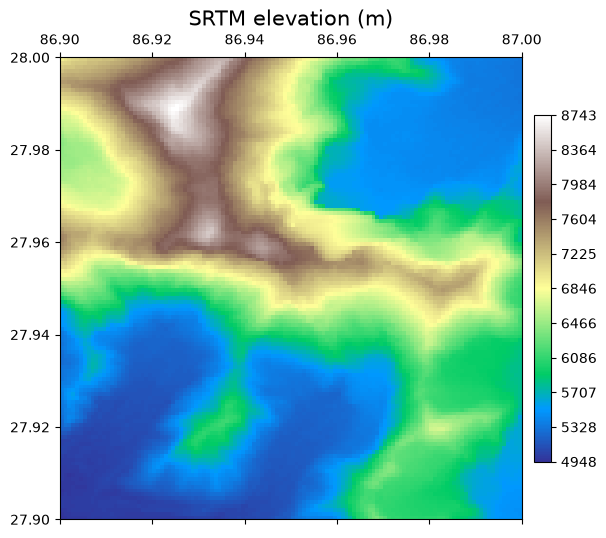

In [5]:
dem.plot(band=0, title="SRTM elevation (m)", cmap="terrain")

The gradient from valley floors to peaks is exactly what you'd expect over the Himalaya — and it came back as a `(1, 120, 120)` EPSG:4326 array we can now treat like any other pyramids raster.

## Controlling the read — resolution, bands, CRS

You place and size the read with a `Window` object, subset bands, and reproject. Pass the window as `window=`:

| `Window` field | Meaning | Example |
| --- | --- | --- |
| `bbox` | area of interest `(min_x, min_y, max_x, max_y)` in `crs` | `Window(bbox=AOI)` |
| `shape=(rows, cols)` | exact output grid | `Window(bbox=AOI, shape=(120, 120))` |
| `scale` | pixel size in `crs` units | `Window(bbox=AOI, scale=0.005)` (≈ 550 m in degrees) |
| `crs` | target CRS (default `EPSG:4326`) | `Window(bbox=AOI, crs="EPSG:3857")` |
| `resample` | how pixels combine when resizing | `Window(bbox=AOI, resample="average")` |

(`bands` stays a top-level argument, e.g. `bands=["B4"]`.) `shape` and `scale` are mutually exclusive. Reading the
same asset with `scale` instead of `shape` gives a coarser grid:

In [ ]:
dem_coarse = from_earthengine(SRTM, window=Window(bbox=AOI, scale=0.005))
dem_coarse.shape

Roughly a 20×20 grid — `0.1` degrees of AOI divided by the `0.005`-degree pixel size.

### Resampling when the grid gets coarser

When the output grid is coarser than the source, `resample` decides how source pixels combine. `nearest` (the default) copies a single source pixel into each output cell — fast, but it throws away the neighbours. `average` takes the mean over each cell's block, which is more faithful for continuous imagery like elevation. `bilinear`, `cubic`, and `mode` are also available. Reading the DEM into a deliberately coarse 24×24 grid both ways shows the difference:

In [ ]:
coarse_near = from_earthengine(
    SRTM, window=Window(bbox=AOI, shape=(24, 24), resample="nearest")
)
coarse_avg = from_earthengine(
    SRTM, window=Window(bbox=AOI, shape=(24, 24), resample="average")
)

coarse_near.plot(band=0, title="resample='nearest'", cmap="terrain")
coarse_avg.plot(band=0, title="resample='average'", cmap="terrain")

`average` blends each block into a smoother field, while `nearest` keeps the blockier picked values — visible along the ridgelines. For downsampled continuous data, prefer `average` or `bilinear`.

## Clip to a polygon

Real areas of interest are rarely rectangles. Pass a `geometry` (a geopandas `GeoDataFrame`) and the reader uses
its envelope as the read window, then **clips the result to the polygon cutline**. A geometry in another CRS is
reprojected to `crs` automatically.

In [8]:
import geopandas as gpd
from shapely.geometry import Polygon

basin = gpd.GeoDataFrame(
    geometry=[Polygon([(86.9, 27.9), (87.0, 27.9), (86.9, 28.0)])],
    crs="EPSG:4326",
)

In [ ]:
dem_clip = from_earthengine(SRTM, window=Window(shape=(120, 120)), geometry=basin)
dem_clip.plot(band=0, title="SRTM clipped to a triangular AOI", cmap="terrain")

Everything outside the triangle is masked to nodata (shown blank) — the elevation only survives inside the polygon, while the bounding box still set the read window.

## Composite an `ImageCollection`

Give `from_earthengine` a `start`/`end` date range **and** a `reducer` and it reads every scene in the collection
over the AOI and reduces them client-side into a single composite `Dataset`. This is how you turn a cloudy image
stack into one clean layer.

| `reducer` | Result per pixel |
| --- | --- |
| `median`, `mean` | central tendency (floating output) |
| `min`, `max` | extremes |
| `sum` | total |
| `mode` | most frequent value |
| `mosaic` | first non-nodata value down the stack |

Here: a **median** RGB composite of Sentinel-2 surface reflectance over two weeks (median suppresses transient
clouds):

In [ ]:
s2 = from_earthengine(
    "COPERNICUS/S2_SR_HARMONIZED",
    window=Window(bbox=AOI, shape=(96, 96)),
    start="2024-06-01",
    end="2024-06-08",
    reducer="median",
    bands=["B4", "B3", "B2"],
)
s2.shape

C:\python-environments\pixi\envs\pyramids-eo-18169666414848982684\envs\dev\Lib\site-packages\numpy\lib\_function_base_impl.py:4798: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(


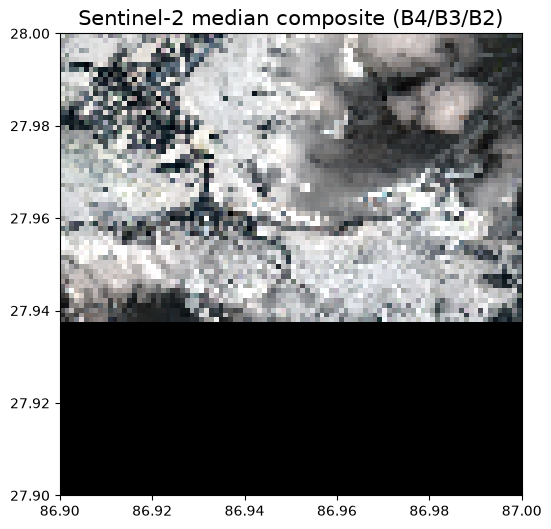

In [11]:
s2.plot(
    rgb_options={"rgb": [0, 1, 2], "percentile": 2},
    title="Sentinel-2 median composite (B4/B3/B2)",
)

Three bands (red/green/blue) came back as a `(3, 96, 96)` composite — the median over every June scene in the window, rendered as a true-colour image.

## Keep every scene — `collection_from_earthengine`

When you want the time series rather than a single composite, `collection_from_earthengine` returns a
`DatasetCollection` with **one aligned `Dataset` per scene** and the acquisition times as its time axis.

In [ ]:
scenes = collection_from_earthengine(
    "COPERNICUS/S2_SR_HARMONIZED",
    start="2024-06-05",
    end="2024-06-08",
    window=Window(bbox=AOI, shape=(96, 96)),
    bands=["B4"],
)
scenes.time_length, list(scenes.time)[:3]

Each timestep is a `Dataset` you can index and plot — here the red band of the first scene:

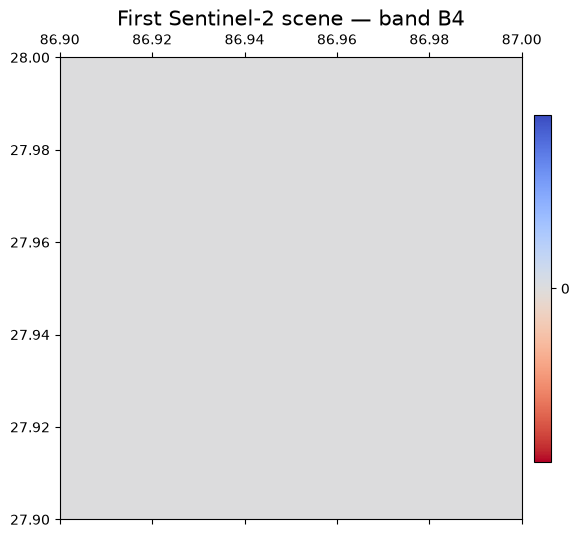

In [13]:
scenes.datasets[0].plot(band=0, title="First Sentinel-2 scene — band B4")

## Takeaway

You can now read Earth Engine into pyramids with three calls:

- `from_earthengine(asset_id, window=Window(bbox=..., shape=/scale=, crs=...), bands=...)` for a **single `Image`**;
- add `start`, `end`, `reducer` (and optionally a `geometry` cutline) for an **`ImageCollection` composite**;
- `collection_from_earthengine(asset_id, start, end, window=Window(...), ...)` for a **per-scene `DatasetCollection`**.

Everything returns a standard pyramids `Dataset` / `DatasetCollection`, so from here you'd continue with the rest
of pyramids — `to_crs`, `crop`, `to_file` (GeoTIFF/COG), aggregation, and plotting. No `earthengine-api` required.